# Laporan Pemodelan Deep Learning untuk Klasifikasi Citra

Notebook ini membahas proses pelatihan model klasifikasi citra menggunakan arsitektur ResNet50 yang dimodifikasi dengan beberapa lapisan tambahan. Dataset yang digunakan kemungkinan terdiri dari gambar 2 object berbeda, masing-masing object memiliki 100 gambar. Setiap gambar diberi posisi dan tempat berbeda terhadap viewport.

Nama: Ahmad Mukhlis Farhan

NIM: 442023611001

# Import Libraries

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

Sel ini mengimpor seluruh library yang dibutuhkan untuk proses:

* manipulasi data (numpy, pandas),

* visualisasi (matplotlib, seaborn),

* manajemen file sistem (os, shutil),

* pemodelan machine learning (scikit-learn, tensorflow, keras).

Model utama menggunakan arsitektur pretrained ResNet50 yang umum untuk klasifikasi citra.

# 1. Persiapan Dataset

In [12]:
# Tentukan path ke direktori dataset
data_dir = '/kaggle/input/2-objects-100-each'
class_names = ['Object 1', 'Object 2']
display_names = ['Deodrant', 'balsem Vicks Vaporub']

# Cek apakah direktori dataset ada
if not os.path.exists(data_dir):
    print("Direktori dataset tidak ditemukan. Pastikan Anda mengunggahnya ke Kaggle.")
    
# Cek jumlah gambar di setiap kelas
for class_name in class_names:
    class_path = os.path.join(data_dir, class_name)
    num_images = len(os.listdir(class_path))
    print(f"Jumlah gambar di kelas '{class_name}': {num_images}")

Jumlah gambar di kelas 'Object 1': 100
Jumlah gambar di kelas 'Object 2': 100


Menentukan path ke folder dataset.

# 2. Augmentasi Data dan Split Dataset

In [13]:
# Tentukan parameter untuk generator gambar
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Inisialisasi generator data untuk pelatihan dan validasi
# Augmentasi data dilakukan untuk meningkatkan variasi dataset
datagen = ImageDataGenerator(
    rescale=1./255,          # Normalisasi piksel
    validation_split=0.2,    # Membagi 20% data untuk validasi
    rotation_range=20,       # Rotasi gambar
    width_shift_range=0.2,   # Menggeser gambar secara horizontal
    height_shift_range=0.2,  # Menggeser gambar secara vertikal
    shear_range=0.2,         # Shear transformation
    zoom_range=0.2,          # Zoom pada gambar
    horizontal_flip=True,    # Membalik gambar secara horizontal
    fill_mode='nearest'      # Mengisi piksel yang kosong
)

# Generator untuk data pelatihan
train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Klasifikasi biner (dua kelas)
    subset='training'
)

# Generator untuk data validasi
validation_generator = datagen.flow_from_directory(
    data_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 160 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


# 3. Implementasi Transfer Learning dengan ResNet50

In [14]:
# Muat model dasar ResNet50 dengan bobot ImageNet
base_model = ResNet50(
    weights='imagenet',        # Gunakan bobot pretrained dari ImageNet
    include_top=False,         # Jangan menyertakan fully-connected layer di atas
    input_shape=(224, 224, 3)  # Tentukan ukuran input
)

# Bekukan (freeze) layer dasar agar tidak dilatih ulang
for layer in base_model.layers:
    layer.trainable = False

# Tambahkan layer baru di atas model dasar
x = base_model.output
x = GlobalAveragePooling2D()(x) # Global average pooling layer
x = Dense(1024, activation='relu')(x) # Dense layer
predictions = Dense(1, activation='sigmoid')(x) # Output layer untuk klasifikasi biner

# Buat model akhir
model = Model(inputs=base_model.input, outputs=predictions)

# Kompilasi model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# Tampilkan ringkasan model
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 25,686,913 (97.99 MB)

 Trainable params: 2,099,201 (8.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# 4. Pelatihan Model

In [15]:
EPOCHS = 20 # Anda bisa menyesuaikan jumlah epoch

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5189 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6903
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step - accuracy: 0.5352 - loss: 0.6887 - val_accuracy: 0.5312 - val_loss: 0.6873
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.4266 - loss: 0.6997 - val_accuracy: 0.5000 - val_loss: 0.6865
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.5364 - loss: 0.6812 - val_accuracy: 0.6250 - val_loss: 0.6872
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.6354 - loss: 0.6835 - val_accuracy: 0.5938 - val_loss: 0.6745
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.5317 - loss: 0.6857 - val_accuracy: 0.7500 - val_loss: 0.6792
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5455 - loss: 0.6821 - val_accuracy: 0.5312 - val_loss: 0.6814
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5926 - loss: 0.6776 - val_accuracy: 0.6562 - val_loss: 0.6846
Epoch 9/

# 5. Visualisasi Hasil

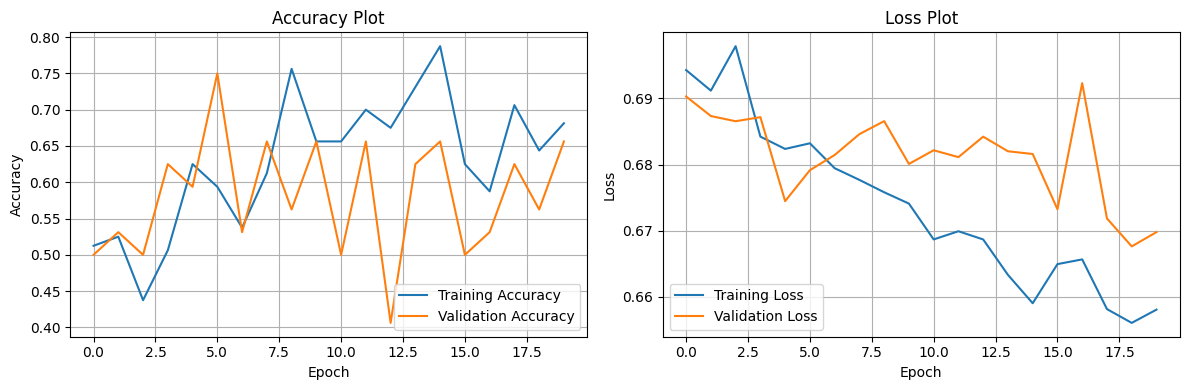

In [16]:
# Plot akurasi pelatihan dan validasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Plot')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss pelatihan dan validasi
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Plot')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Evaluasi Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step


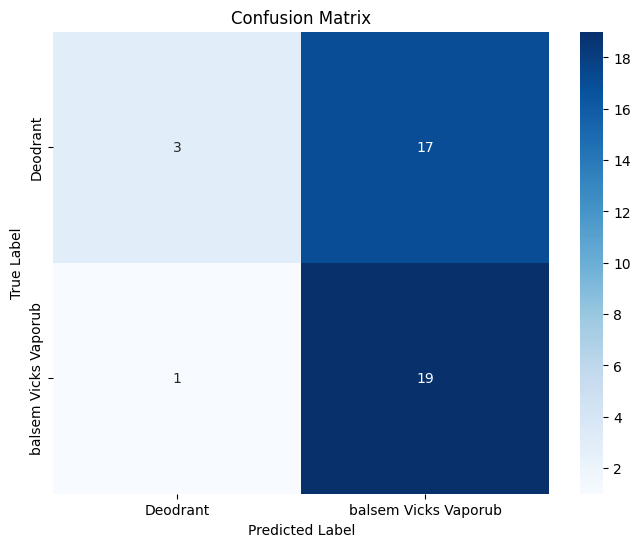

Classification Report:
                      precision    recall  f1-score   support

            Deodrant       0.75      0.15      0.25        20
balsem Vicks Vaporub       0.53      0.95      0.68        20

            accuracy                           0.55        40
           macro avg       0.64      0.55      0.46        40
        weighted avg       0.64      0.55      0.46        40



In [17]:
# Prediksi pada data validasi
validation_generator.reset()
y_pred = model.predict(validation_generator)
y_pred_classes = (y_pred > 0.5).astype(int)
y_true = validation_generator.classes

# Buat confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=display_names, yticklabels=display_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Cetak classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=display_names))

# 7. Uji Klasifikasi Gambar Tunggal

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


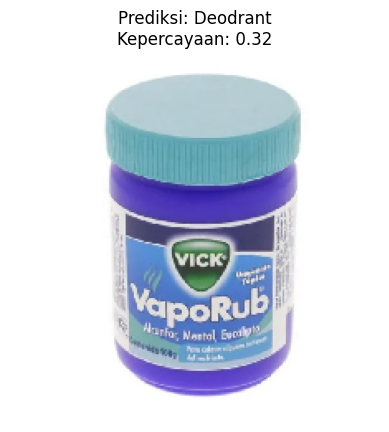

Hasil Prediksi: Deodrant
Nilai kepercayaan (confidence score): 0.3233


In [18]:
# Tentukan path gambar yang akan diuji
# Ganti 'path/ke/gambar/anda.jpg' dengan path gambar yang sebenarnya di direktori Kaggle Anda
image_path = '/kaggle/input/vicks-test/vicks.jpg' 

# Lakukan pra-pemrosesan gambar
try:
    img = load_img(image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Tambahkan dimensi batch
    img_array /= 255.0  # Normalisasi piksel
    
    # Lakukan prediksi
    prediction = model.predict(img_array)
    predicted_class = (prediction > 0.5).astype(int)
    confidence = prediction[0][0]
    
    # Tampilkan gambar dan hasil prediksi
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediksi: {display_names[predicted_class[0][0]]}\nKepercayaan: {confidence:.2f}")
    plt.show()
    
    print(f"Hasil Prediksi: {display_names[predicted_class[0][0]]}")
    print(f"Nilai kepercayaan (confidence score): {confidence:.4f}")

except FileNotFoundError:
    print(f"Error: File tidak ditemukan di path: {image_path}")
    print("Pastikan Anda mengganti path gambar dengan benar.")
